# Домашняя работа №1

**Датасет:** Mushroom Classification


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## Загрузка данных

In [23]:
url = 'E:\mine\LLM\mushrooms.csv'
df = pd.read_csv(url)
pd.set_option('display.max_columns', None)

In [24]:
df.shape

(8124, 23)

In [25]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null

In [26]:
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,e,e,s,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,e,c,s,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,e,c,s,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,e,e,s,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,t,e,s,s,w,w,p,w,o,e,n,a,g


In [27]:
df.describe().round(2)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,2,5,4,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,t,b,s,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,4608,3776,5176,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [39]:
df = df.astype('category')
df.dtypes

class                       category
cap-shape                   category
cap-surface                 category
cap-color                   category
bruises                     category
odor                        category
gill-attachment             category
gill-spacing                category
gill-size                   category
gill-color                  category
stalk-shape                 category
stalk-root                  category
stalk-surface-above-ring    category
stalk-surface-below-ring    category
stalk-color-above-ring      category
stalk-color-below-ring      category
veil-type                   category
veil-color                  category
ring-number                 category
ring-type                   category
spore-print-color           category
population                  category
habitat                     category
dtype: object

### Числовая интерпритация данных

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for column in df.columns:
    df[column] = le.fit_transform(df[column])
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,stalk-root,stalk-surface-above-ring,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,0,3,2,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,0,2,2,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,0,2,2,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,0,3,2,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,1,3,2,2,7,7,0,2,1,0,3,0,1


## EDA

### 1. Распределение классов

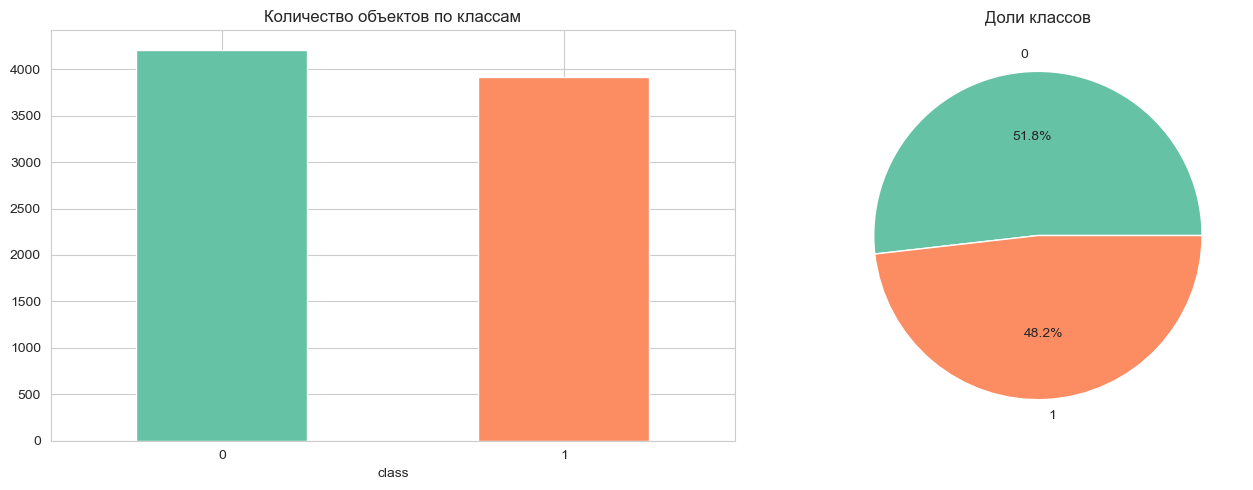

In [44]:
target_col = 'class'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_col].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=0)

df[target_col].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

### 2. Распределение признаков

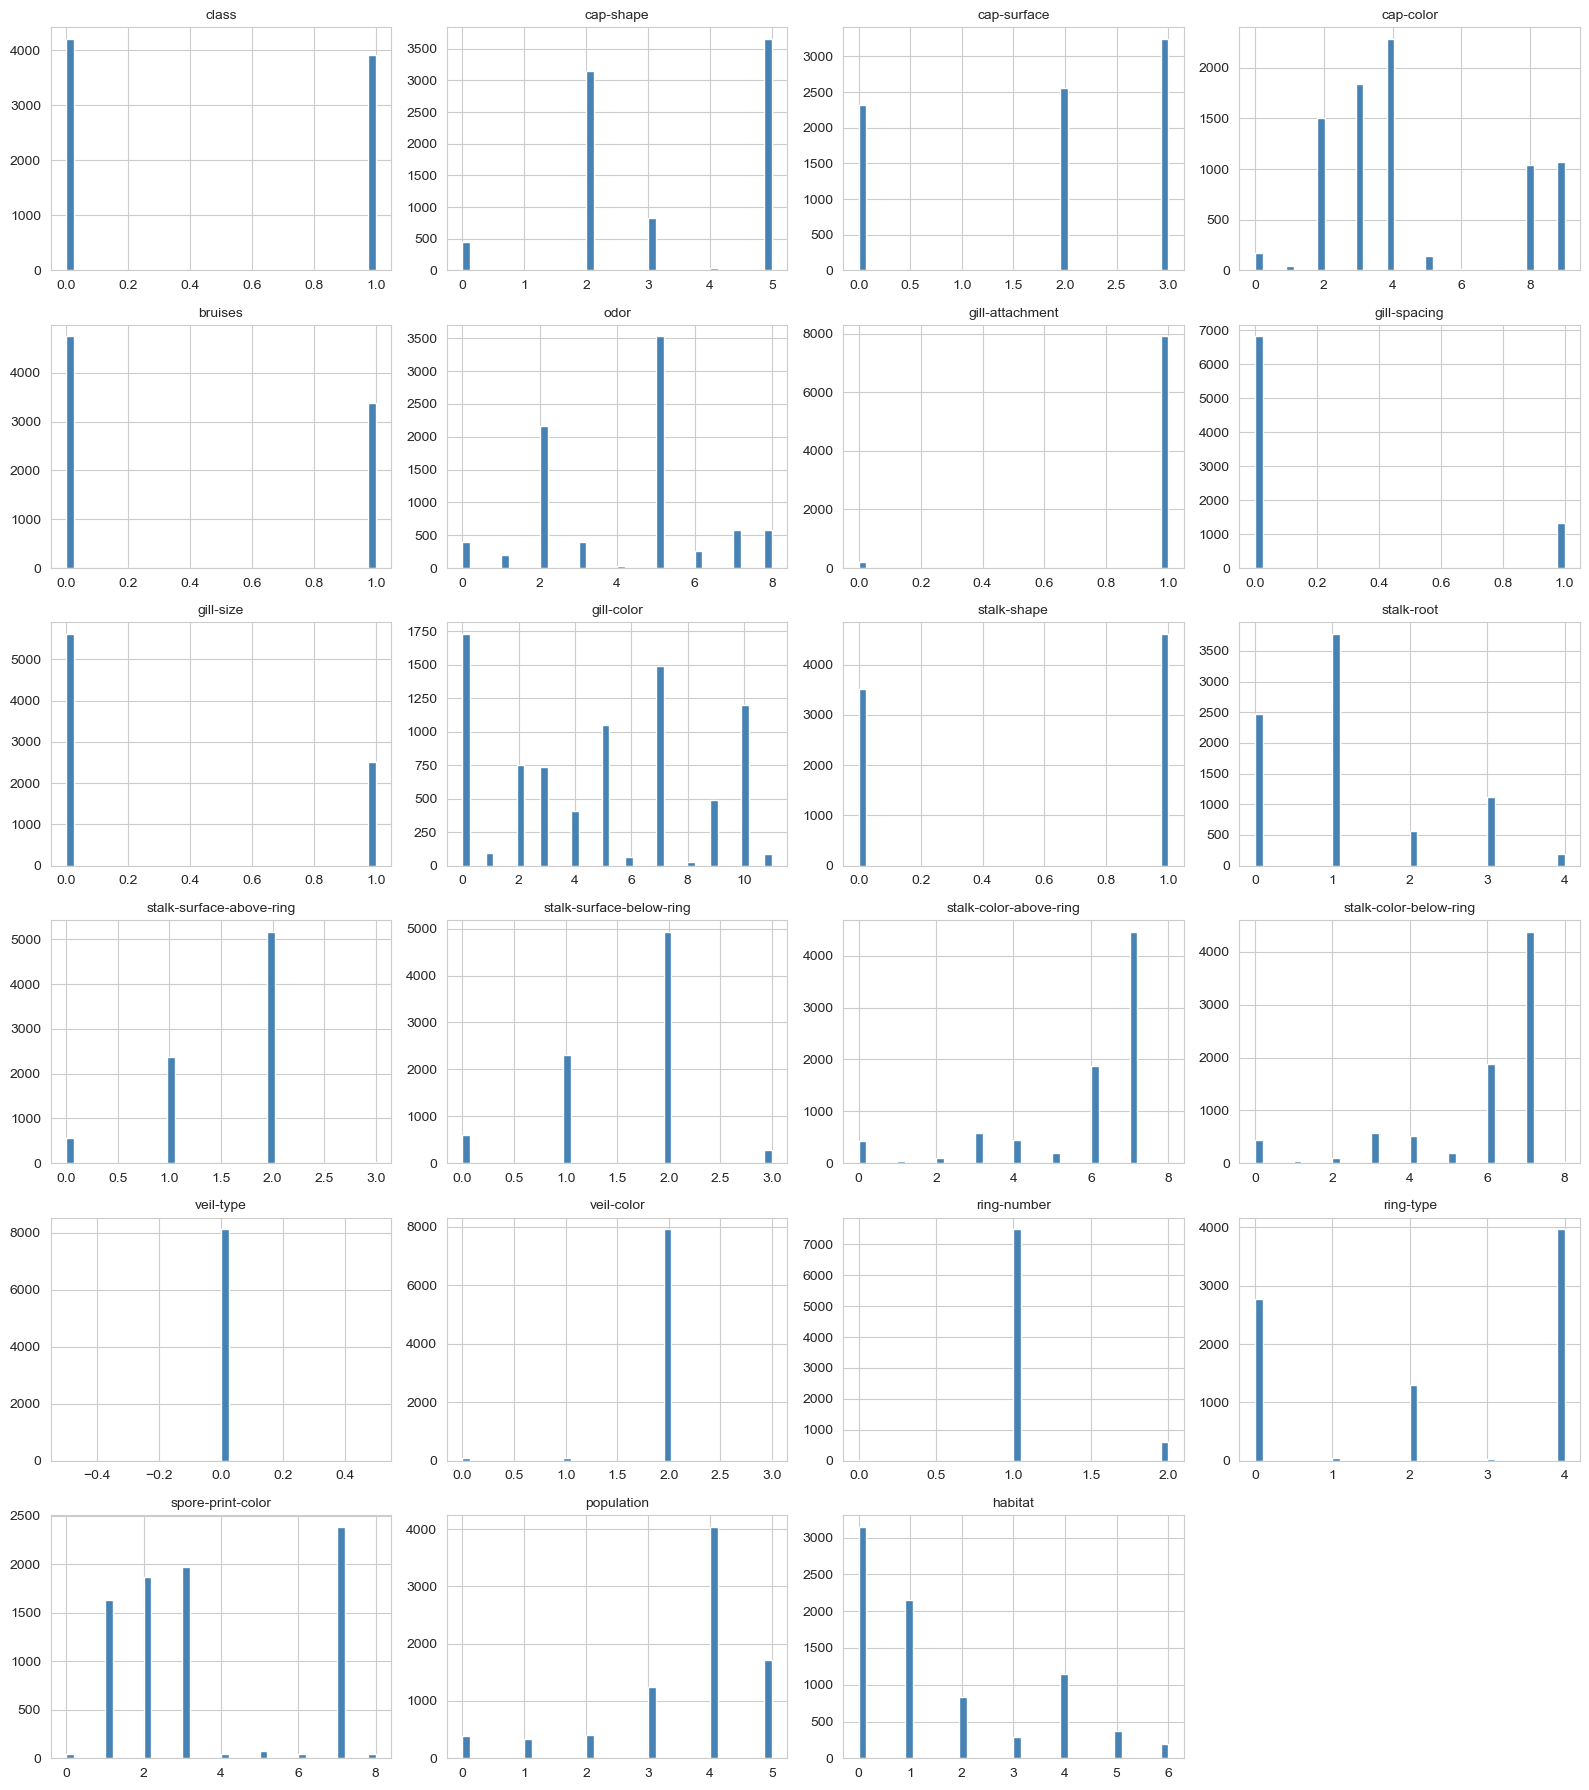

In [47]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4
fig, axes = plt.subplots(n_rows, 4, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### 3. Корреляция между признаками 

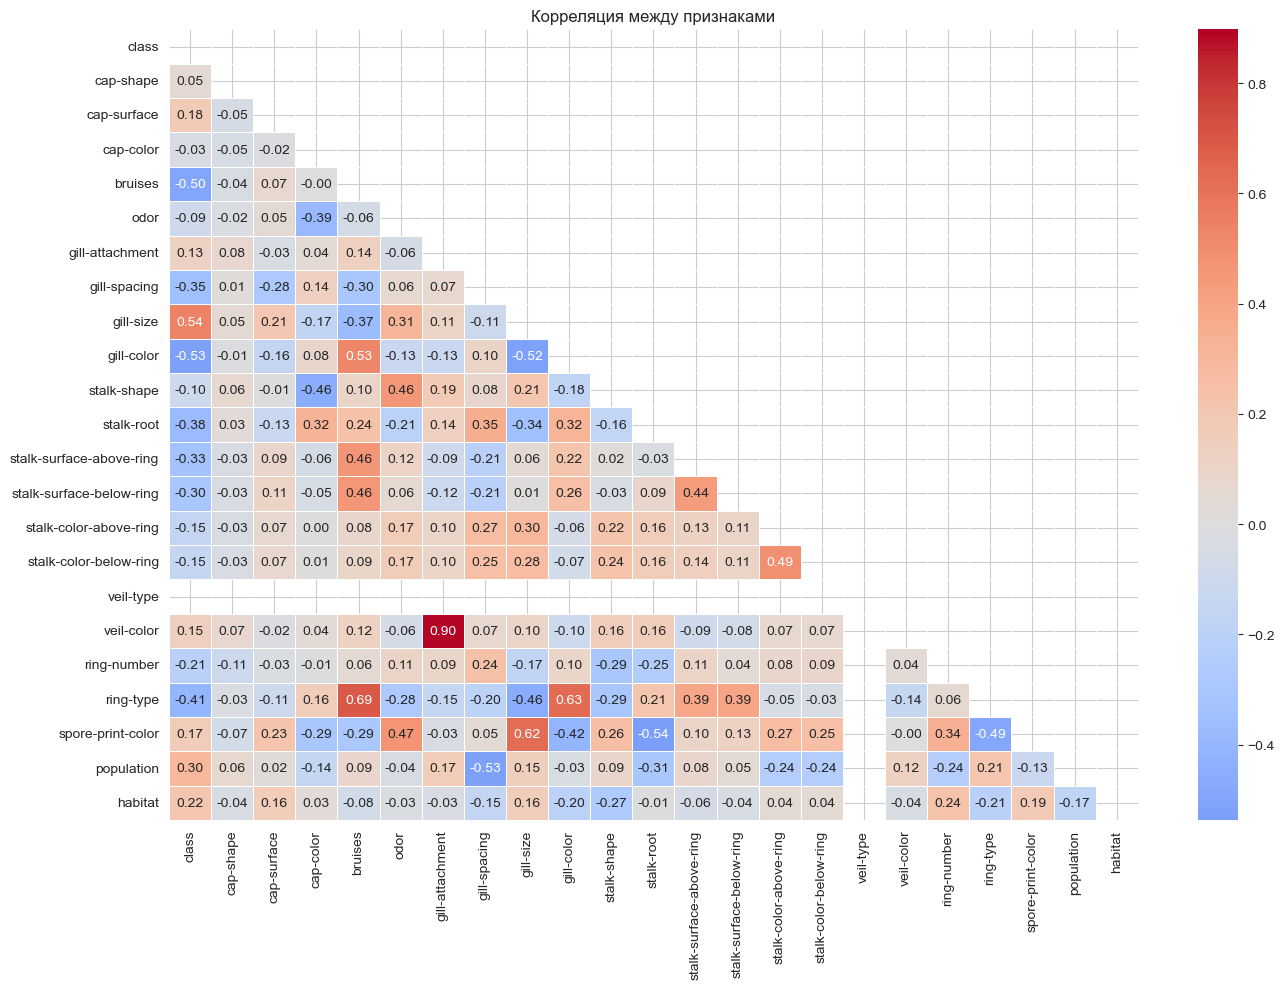

In [49]:
plt.figure(figsize=(14, 10))
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

### 4. Удаление лишних признаков на основе EDA

In [50]:
df.drop(['gill-attachment', 'veil-type', 'veil-color'], axis=1, inplace=True)
df.columns

Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root',
       'stalk-surface-above-ring', 'stalk-surface-below-ring',
       'stalk-color-above-ring', 'stalk-color-below-ring', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='str')

## Подготовка данных 

### 1. Подготовка для классификации

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_cols = ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root',
       'stalk-surface-above-ring', 'stalk-surface-below-ring',
       'stalk-color-above-ring', 'stalk-color-below-ring', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat']
X_all = df[feature_cols].copy()

X_cls = X_all.drop(columns=['class'])
y_cls = LabelEncoder().fit_transform( df[target_col])

X_train, X_test, y_train_cls, y_test_cls =  train_test_split(X_cls, y_cls, test_size=0.2, random_state=123, stratify=y_cls)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

### 2. Создание бинарной задачи (для ROC, PR кривых)

In [105]:
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

scaler_bin = StandardScaler()
X_train_bin_sc = scaler_bin.fit_transform(X_train_bin)
X_test_bin_sc = scaler_bin.transform(X_test_bin)

pd.Series(y_cls).value_counts()

0    4208
1    3916
Name: count, dtype: int64

### 3 Утечка данных: масштабирование внутри Pipeline

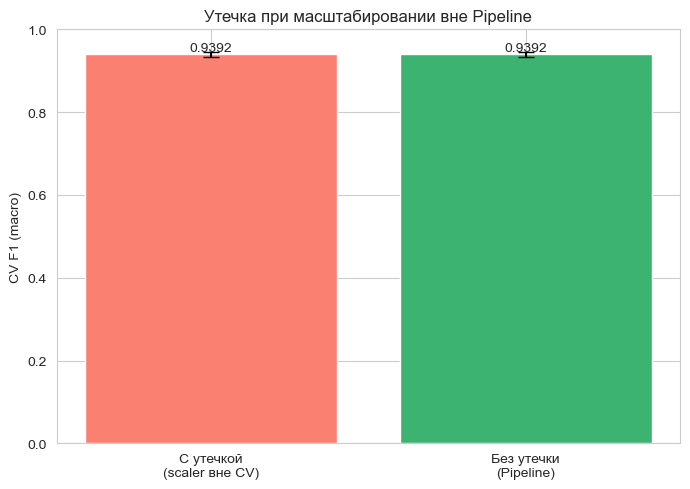

Разница средних CV F1: 0.00000


In [106]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
wrong = cross_val_score(LogisticRegression(), X_train_sc, y_train_cls, cv=cv, scoring='f1_macro')

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('LogisticRegression', LogisticRegression())
])
correct = cross_val_score(pipe, X_train, y_train_cls, cv=cv, scoring='f1_macro')


fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['С утечкой\n(scaler вне CV)', 'Без утечки\n(Pipeline)'],
              [wrong.mean(), correct.mean()],
              yerr=[wrong.std(), correct.std()], capsize=6,
              color=['salmon', 'mediumseagreen'])
for b, v in zip(bars, [wrong.mean(), correct.mean()]):
    ax.text(b.get_x() + b.get_width()/2, v, f'{v:.4f}', ha='center', va='bottom')
ax.set_ylabel('CV F1 (macro)'); ax.set_ylim(0, 1)
ax.set_title('Утечка при масштабировании вне Pipeline')
plt.tight_layout(); plt.show()

print(f'Разница средних CV F1: {abs(wrong.mean() - correct.mean()):.5f}')

## Бинарная классификация: Logistic Regression

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, log_loss,
                             roc_auc_score, roc_curve, precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

log_reg_bin = LogisticRegression(max_iter=1000, random_state=1).fit(X_train_bin_sc, y_train_bin)
y_pred_bin = log_reg_bin.predict(X_test_bin_sc)
y_proba_bin = log_reg_bin.predict_proba(X_test_bin_sc)[:, 1]

f1_score(y_test_bin, y_pred_bin)


0.9426915647134578

### 1. Confusion matrix

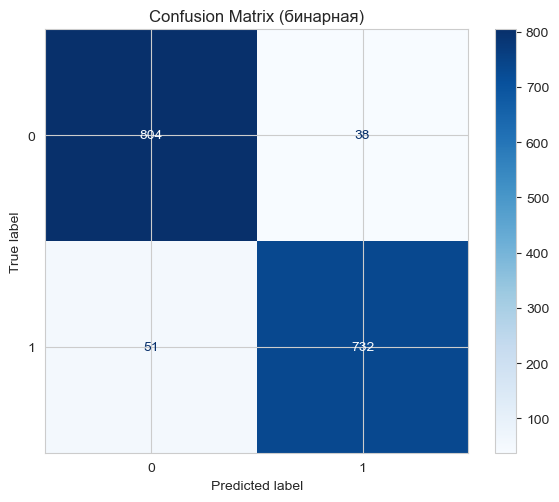

In [148]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_bin, ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix (бинарная)')
plt.tight_layout()
plt.show()

### 2. Precision, Recall, F1, Log-Loss

In [149]:
pd.DataFrame({
    'Accuracy': [accuracy_score(y_test_bin, y_pred_bin)],
    'Precision': [precision_score(y_test_bin, y_pred_bin)],
    'Recall': [recall_score(y_test_bin, y_pred_bin)],
    'F1': [f1_score(y_test_bin, y_pred_bin)],
    'Log-Loss': [log_loss(y_test_bin, y_proba_bin)],
    'ROC-AUC': [roc_auc_score(y_test_bin, y_proba_bin)],
}, index=['LogReg (binary)']).round(4)

,Accuracy,Precision,Recall,F1,Log-Loss,ROC-AUC
LogReg (binary),0.9452,0.9506,0.9349,0.9427,0.1886,0.9802


### 3. ROC-кривая и PR-кривая

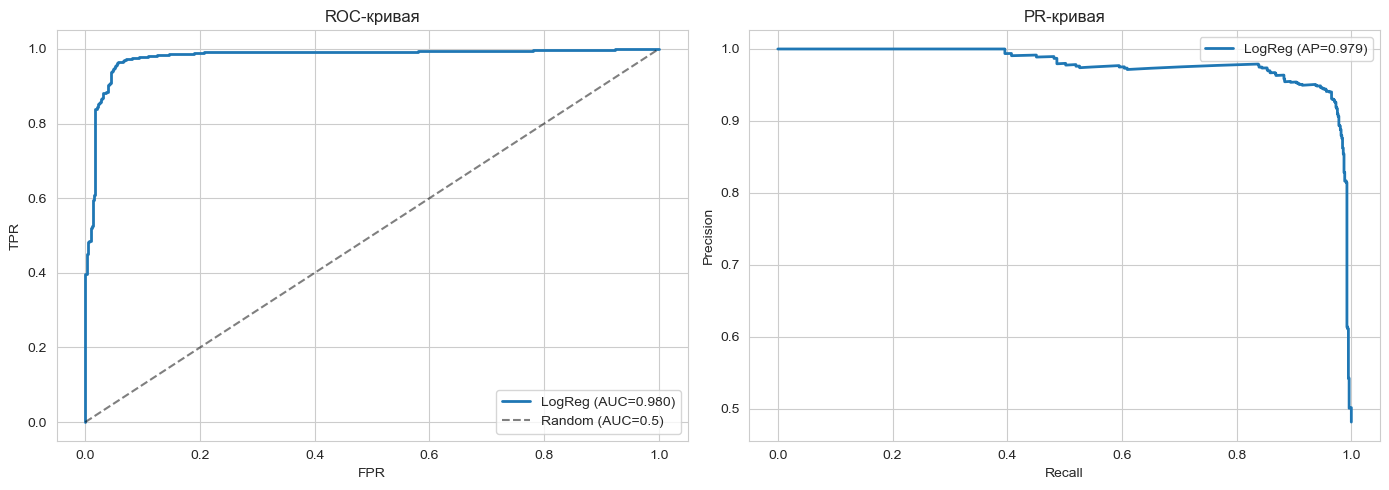

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fpr, tpr, _ = roc_curve(y_test_bin, y_proba_bin)
axes[0].plot(fpr, tpr, linewidth=2, label=f'LogReg (AUC={roc_auc_score(y_test_bin, y_proba_bin):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC-кривая')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test_bin, y_proba_bin)
ap = average_precision_score(y_test_bin, y_proba_bin)
axes[1].plot(rec, prec, linewidth=2, label=f'LogReg (AP={ap:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая')
axes[1].legend()

plt.tight_layout()
plt.show()

### 4. Влияние порога $\tau$ на метрики

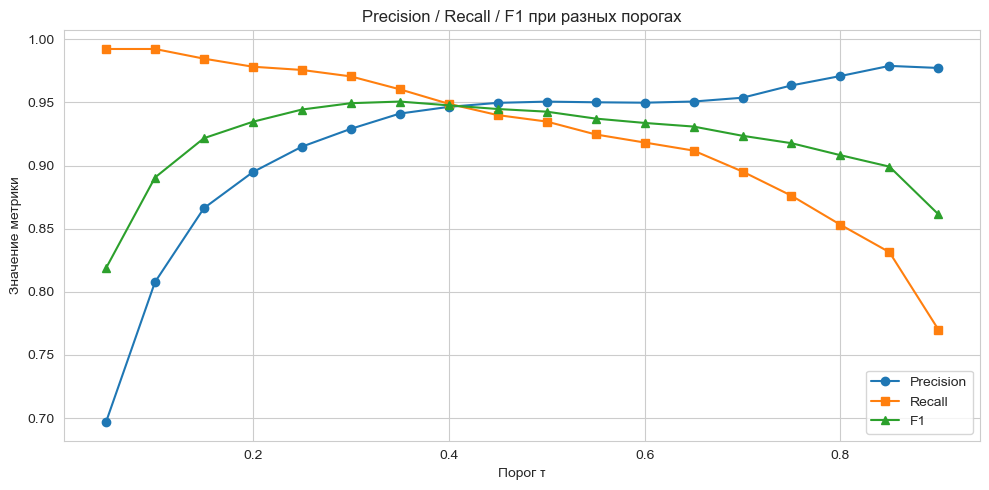

In [151]:
thresholds = np.arange(0.05, 0.95, 0.05)
metrics_by_t = []
for t in thresholds:
    y_t = (y_proba_bin >= t).astype(int)
    metrics_by_t.append({
        'threshold': t,
        'precision': precision_score(y_test_bin, y_t, zero_division=0),
        'recall': recall_score(y_test_bin, y_t, zero_division=0),
        'f1': f1_score(y_test_bin, y_t, zero_division=0),
    })
df_t = pd.DataFrame(metrics_by_t)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_t['threshold'], df_t['precision'], 'o-', label='Precision')
ax.plot(df_t['threshold'], df_t['recall'], 's-', label='Recall')
ax.plot(df_t['threshold'], df_t['f1'], '^-', label='F1')
ax.set_xlabel('Порог τ')
ax.set_ylabel('Значение метрики')
ax.set_title('Precision / Recall / F1 при разных порогах')
ax.legend()
plt.tight_layout()
plt.show()

### 5. Выбор оптимального порога и `class_weight`

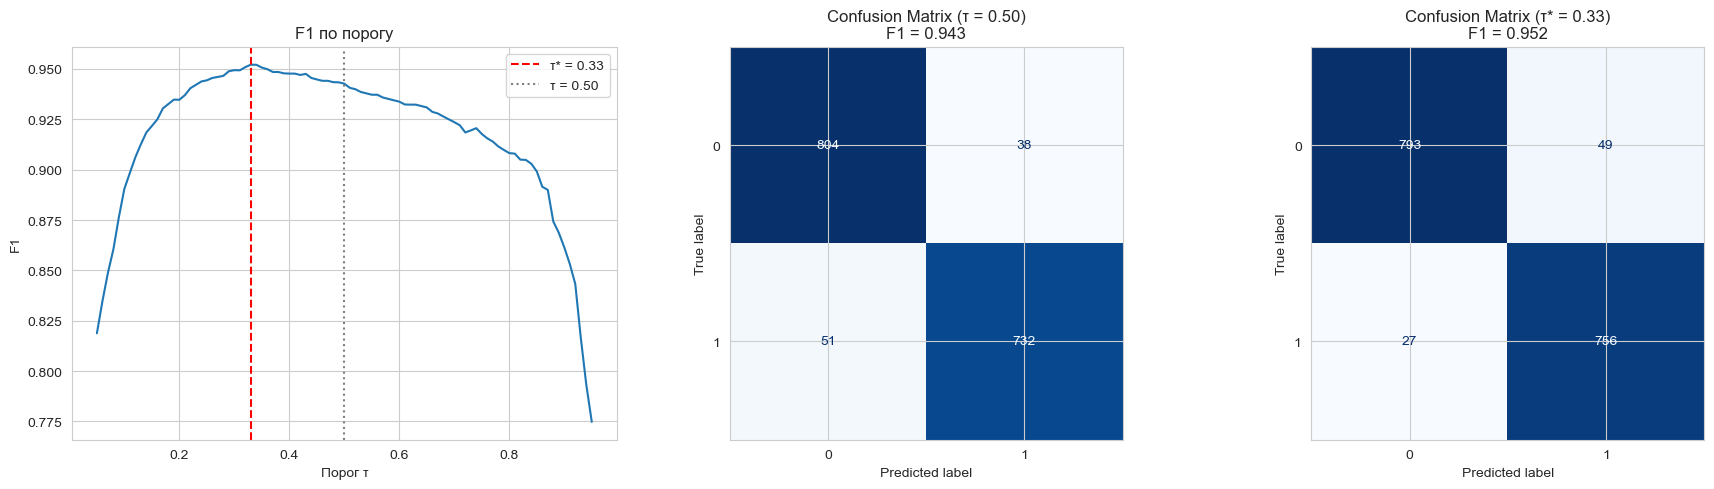

In [152]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

taus = np.linspace(0.05, 0.95, 91)
f1s = [f1_score(y_test_bin, (y_proba_bin >= t).astype(int)) for t in taus]
tau_star = taus[int(np.argmax(f1s))]


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(taus, f1s)
axes[0].axvline(tau_star, color='red', ls='--', label=f'τ* = {tau_star:.2f}')
axes[0].axvline(0.5, color='gray', ls=':', label='τ = 0.50')
axes[0].set_xlabel('Порог τ'); axes[0].set_ylabel('F1'); axes[0].set_title('F1 по порогу'); axes[0].legend()
for ax, t, name in [(axes[1], 0.5, 'τ = 0.50'), (axes[2], tau_star, f'τ* = {tau_star:.2f}')]:
    cm = confusion_matrix(y_test_bin, (y_proba_bin >= t).astype(int))
    ConfusionMatrixDisplay(cm).plot(ax=ax, cmap='Blues', colorbar=False)
    f1v = f1_score(y_test_bin, (y_proba_bin >= t).astype(int))
    ax.set_title(f'Confusion Matrix ({name})\nF1 = {f1v:.3f}')
plt.tight_layout(); plt.show()

### 6. Калибровка вероятностей

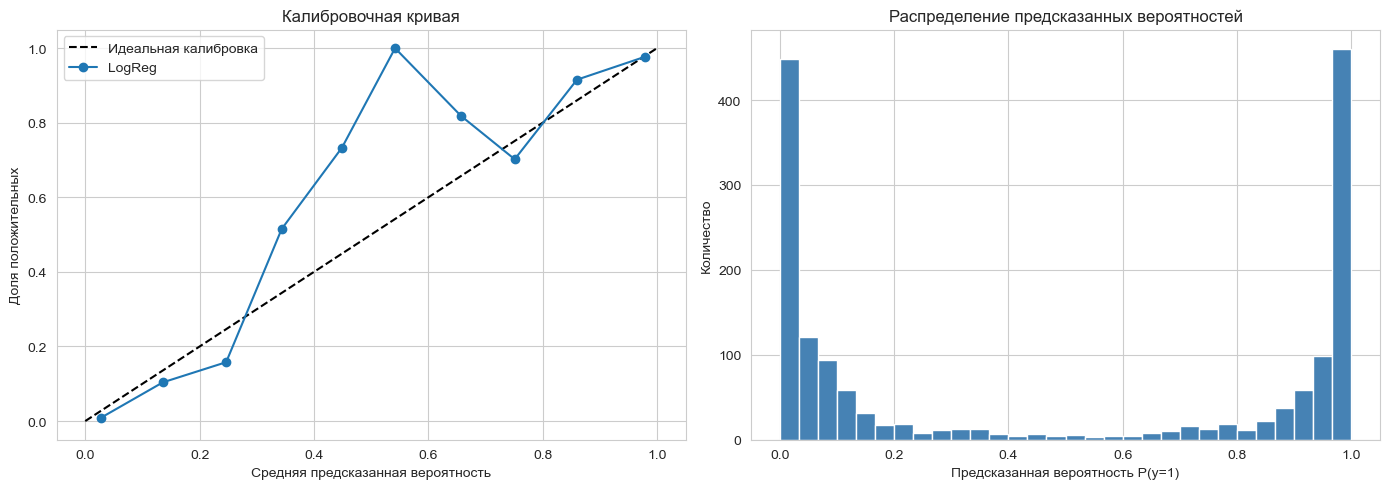

In [153]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(y_test_bin, y_proba_bin, n_bins=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot([0, 1], [0, 1], 'k--', label='Идеальная калибровка')
axes[0].plot(prob_pred, prob_true, 'o-', label='LogReg')
axes[0].set_xlabel('Средняя предсказанная вероятность'); axes[0].set_ylabel('Доля положительных')
axes[0].set_title('Калибровочная кривая'); axes[0].legend()
axes[1].hist(y_proba_bin, bins=30, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Предсказанная вероятность P(y=1)'); axes[1].set_ylabel('Количество')
axes[1].set_title('Распределение предсказанных вероятностей')
plt.tight_layout(); plt.show()

### 7. Граница решения

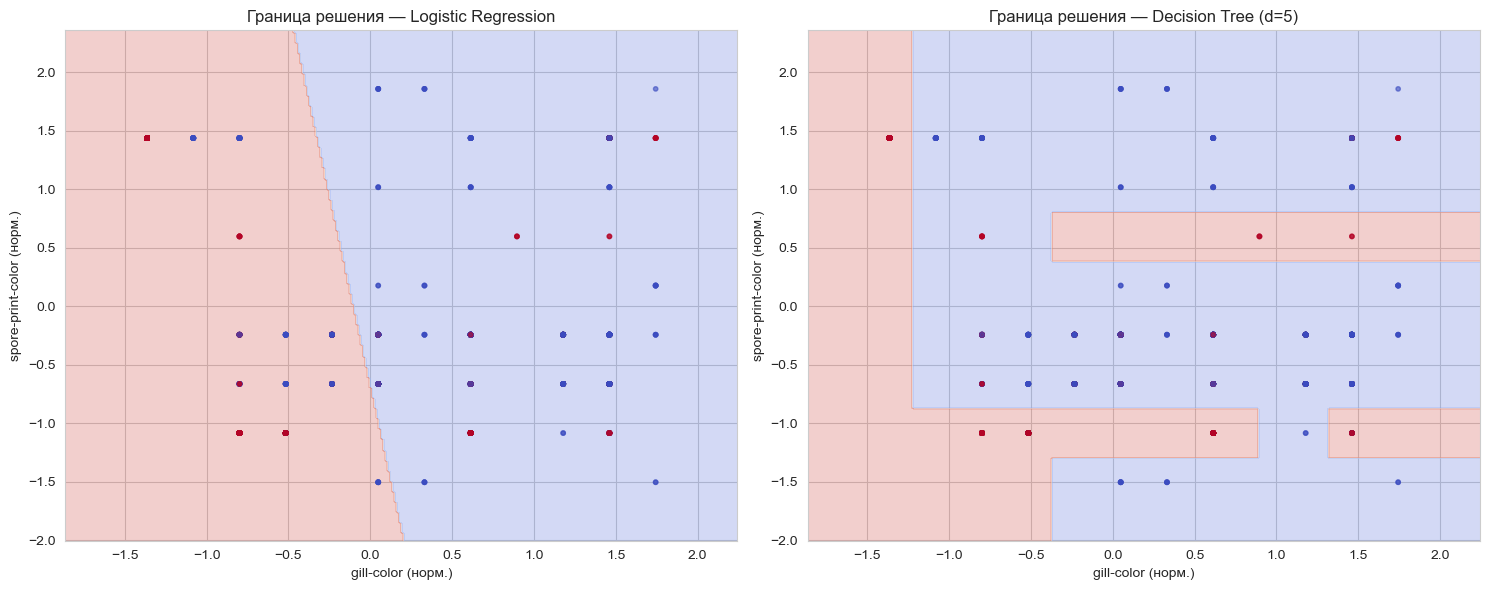

In [155]:
from sklearn.tree import DecisionTreeClassifier
X = X_all
f1n, f2n = 'gill-color', 'spore-print-color'
Xb2 = X[[f1n, f2n]].values
Xb2_tr, Xb2_te, yb_tr, yb_te = train_test_split(Xb2, y_cls, test_size=0.2, random_state=42, stratify=y_cls)
sc2 = StandardScaler().fit(Xb2_tr)
Xb2_tr_s, Xb2_te_s = sc2.transform(Xb2_tr), sc2.transform(Xb2_te)

lr2 = LogisticRegression(max_iter=1000, random_state=42).fit(Xb2_tr_s, yb_tr)
dt2 = DecisionTreeClassifier(max_depth=5, random_state=42).fit(Xb2_tr_s, yb_tr)

xmin, xmax = Xb2_te_s[:, 0].min() - 0.5, Xb2_te_s[:, 0].max() + 0.5
ymin, ymax = Xb2_te_s[:, 1].min() - 0.5, Xb2_te_s[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 300), np.linspace(ymin, ymax, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

rng = np.random.RandomState(42)
idx = rng.choice(len(Xb2_te_s), size=min(2000, len(Xb2_te_s)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, model, name in [(axes[0], lr2, 'Logistic Regression'), (axes[1], dt2, 'Decision Tree (d=5)')]:
    Z = model.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='coolwarm')
    ax.scatter(Xb2_te_s[idx, 0], Xb2_te_s[idx, 1], c=yb_te[idx], cmap='coolwarm', s=10, alpha=0.6)
    ax.set_xlabel(f'{f1n} (норм.)'); ax.set_ylabel(f'{f2n} (норм.)')
    ax.set_title(f'Граница решения — {name}')
plt.tight_layout(); plt.show()

## Деревья решений

### 1. Дерево для классификации

In [136]:
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

dt_cls = DecisionTreeClassifier(max_depth=5, random_state=2, criterion='gini')
dt_cls.fit(X_train, y_train_cls)
y_pred_dt = dt_cls.predict(X_test)

pd.DataFrame({
    'Accuracy': [accuracy_score(y_test_cls, y_pred_dt)],
    'F1 (macro)': [f1_score(y_test_cls, y_pred_dt, average='macro')],
}, index=['DecisionTree (depth=5)']).round(4)

,Accuracy,F1 (macro)
DecisionTree (depth=5),0.9735,0.9735


### 2. Визуализация дерева


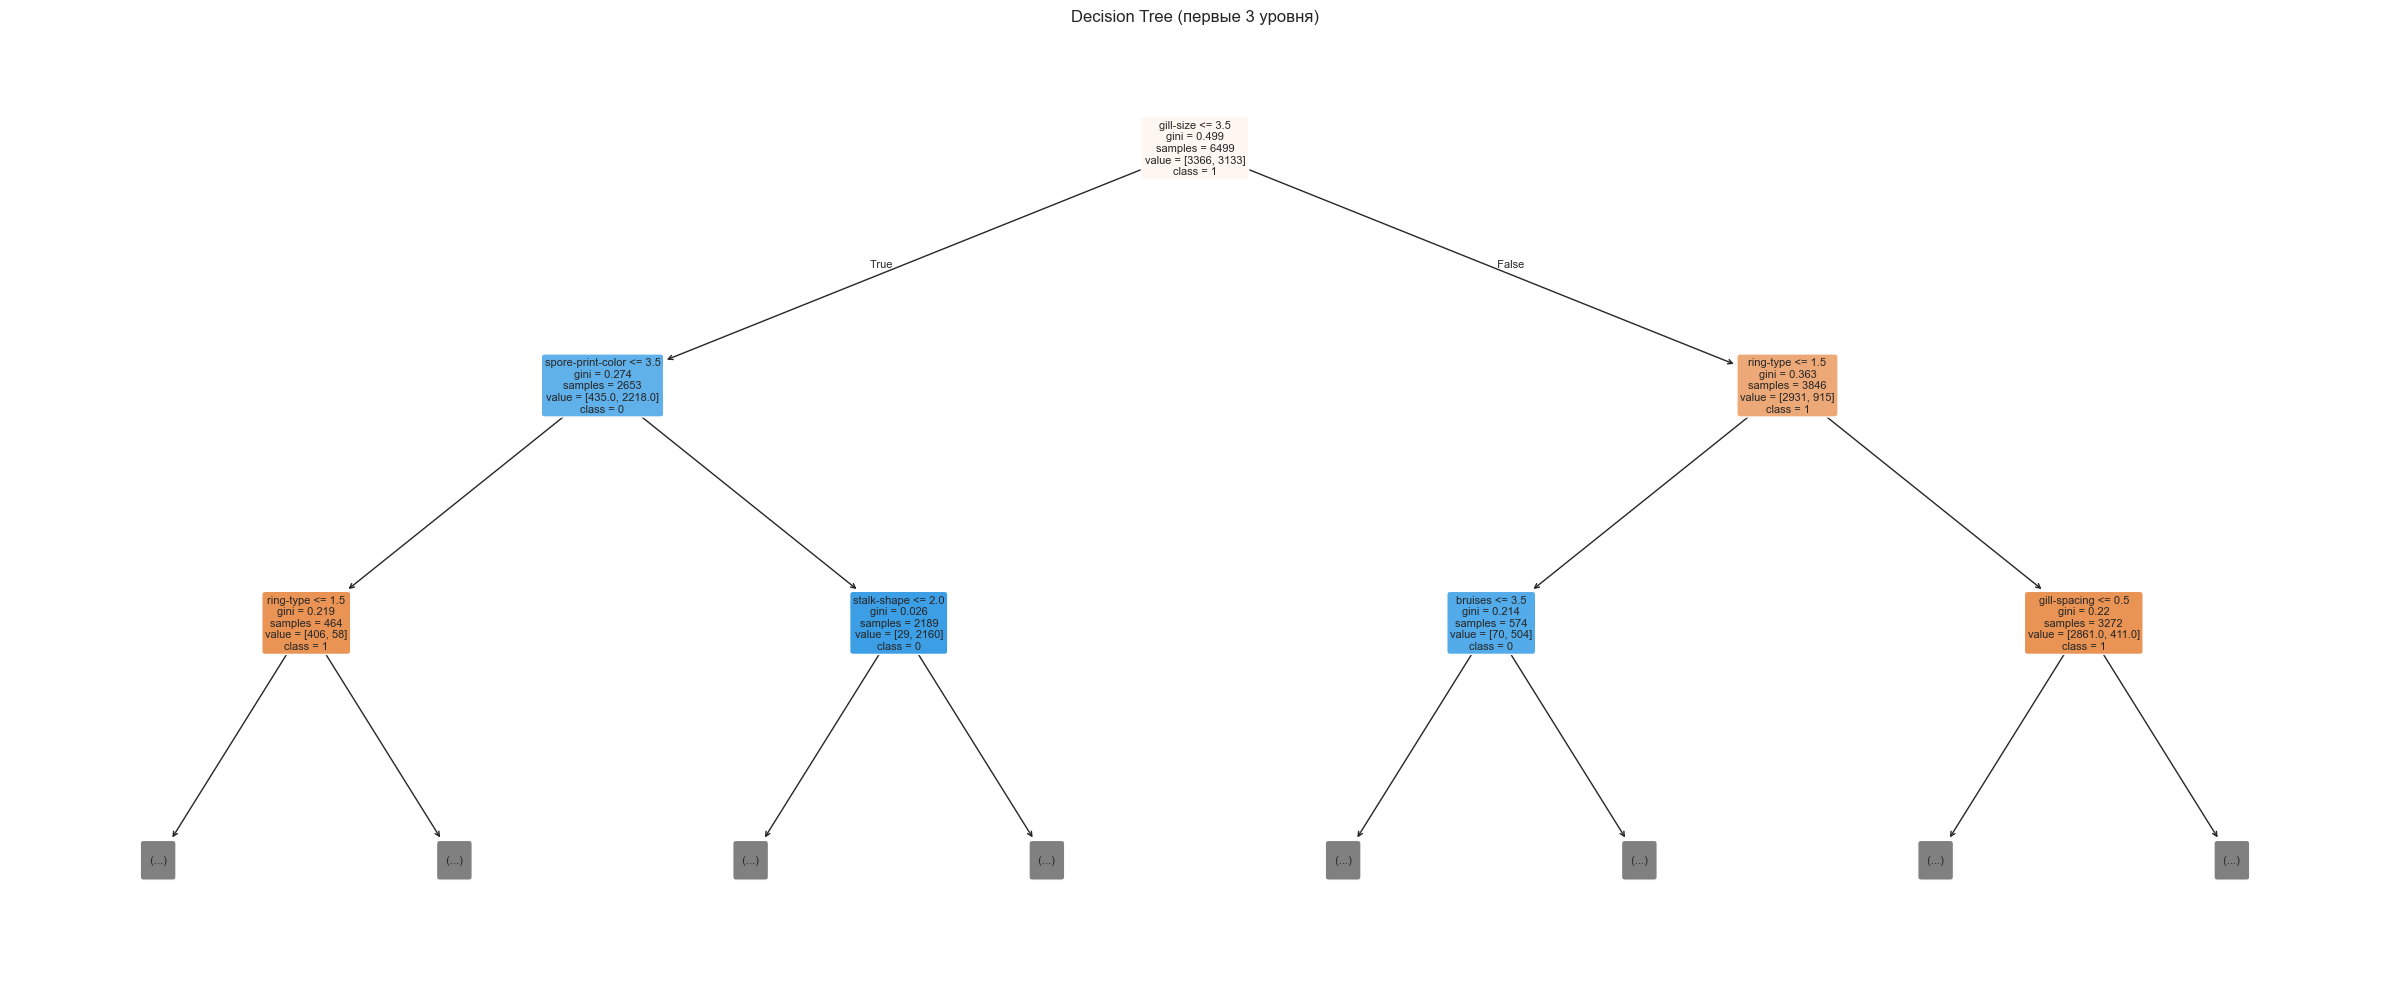

In [145]:
numeric_cols = X.columns.tolist()

plt.figure(figsize=(24, 10))
plot_tree(dt_cls, max_depth=2, feature_names=numeric_cols,
          class_names=df['class'].unique().astype(str).tolist(), filled=True, rounded=True, fontsize=8)
plt.title('Decision Tree (первые 3 уровня)')
plt.tight_layout()
plt.show()

### 3. ROC и PR-кривые нескольких моделей (бинарная задача)


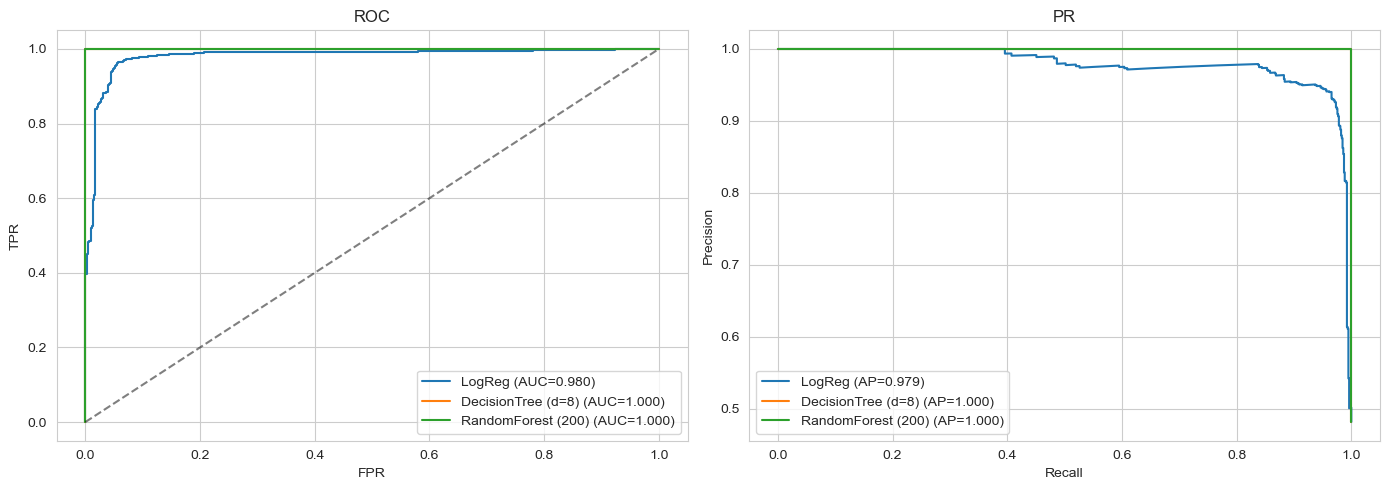

In [146]:
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
models_bin = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree (d=8)': DecisionTreeClassifier(max_depth=8, random_state=42),
    'RandomForest (200)': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, model in models_bin.items():
    model.fit(X_train_bin_sc, y_train_bin)
    proba = model.predict_proba(X_test_bin_sc)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_bin, proba)
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_test_bin, proba):.3f})')
    prec, rec, _ = precision_recall_curve(y_test_bin, proba)
    axes[1].plot(rec, prec, label=f'{name} (AP={average_precision_score(y_test_bin, proba):.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC'); axes[0].legend()
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].set_title('PR'); axes[1].legend()
plt.tight_layout(); plt.show()

## Переобучение и Bias-Variance Tradeoff

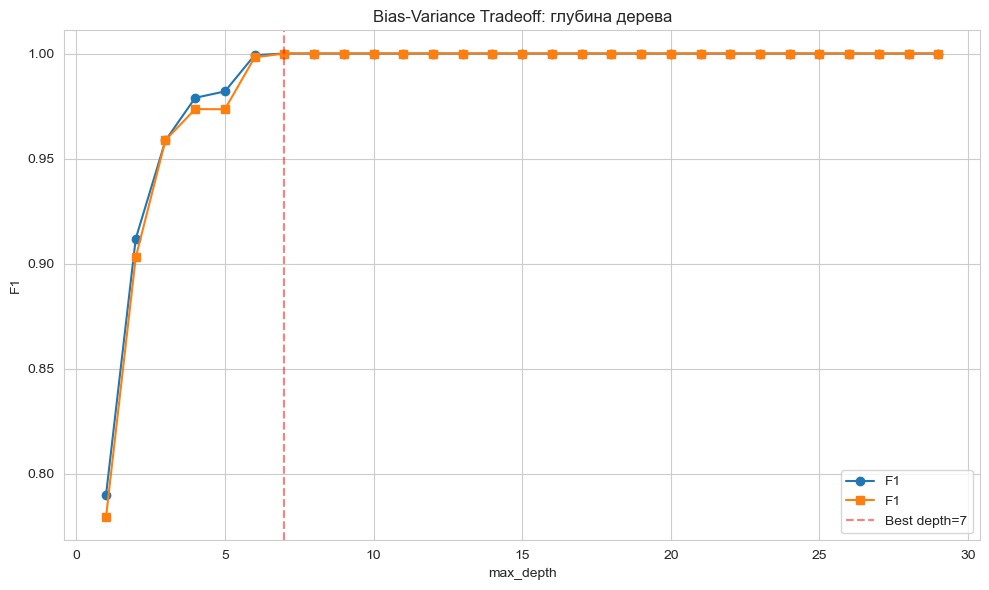

In [ ]:
depths = range(1, 30)
train_acc, test_acc = [], []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=2).fit(X_train, y_train_cls)
    train_acc.append(f1_score(y_train_cls, dt.predict(X_train), average='macro'))
    test_acc.append(f1_score(y_test_cls, dt.predict(X_test), average='macro'))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(depths, train_acc, 'o-', label='F1')
ax.plot(depths, test_acc, 's-', label='F1')
ax.axvline(x=depths[np.argmax(test_acc)], color='red', linestyle='--', alpha=0.5,
           label=f'Best depth={depths[np.argmax(test_acc)]}')
ax.set_xlabel('max_depth')
ax.set_ylabel('F1')
ax.set_title('Bias-Variance Tradeoff: глубина дерева')
ax.legend()
plt.tight_layout()
plt.show()

## Кросс-валидация и подбор гиперпараметров

### 1. Кросс-валидация

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2)

models_cv = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=2),
    'DecisionTree (d=5)': DecisionTreeClassifier(max_depth=5, random_state=2),
    'DecisionTree (d=None)': DecisionTreeClassifier(random_state=2),
}

cv_results = []
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_sc, y_train_cls, cv=cv, scoring='f1_macro')
    cv_results.append({'Model': name, 'CV F1 mean': scores.mean(), 'CV F1 std': scores.std()})

pd.DataFrame(cv_results).set_index('Model').round(4)

,CV F1 mean,CV F1 std
Model,,
LogReg,0.9397,0.0083
DecisionTree (d=5),0.9817,0.0038
DecisionTree (d=None),1.0000,0.0000


### 2. GridSearchCV — подбор гиперпараметров дерева

In [ ]:
param_grid = {
    'max_depth': [3, 5, 7, 10, 15, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=2),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1
)
grid_search.fit(X_train_sc, y_train_cls)

grid_search.best_params_, grid_search.best_score_.round(4)

({'criterion': 'gini',
  'max_depth': 7,
  'min_samples_leaf': 1,
  'min_samples_split': 2},
 np.float64(1.0))

## Анализ признаков 

### 1. По дереву решений

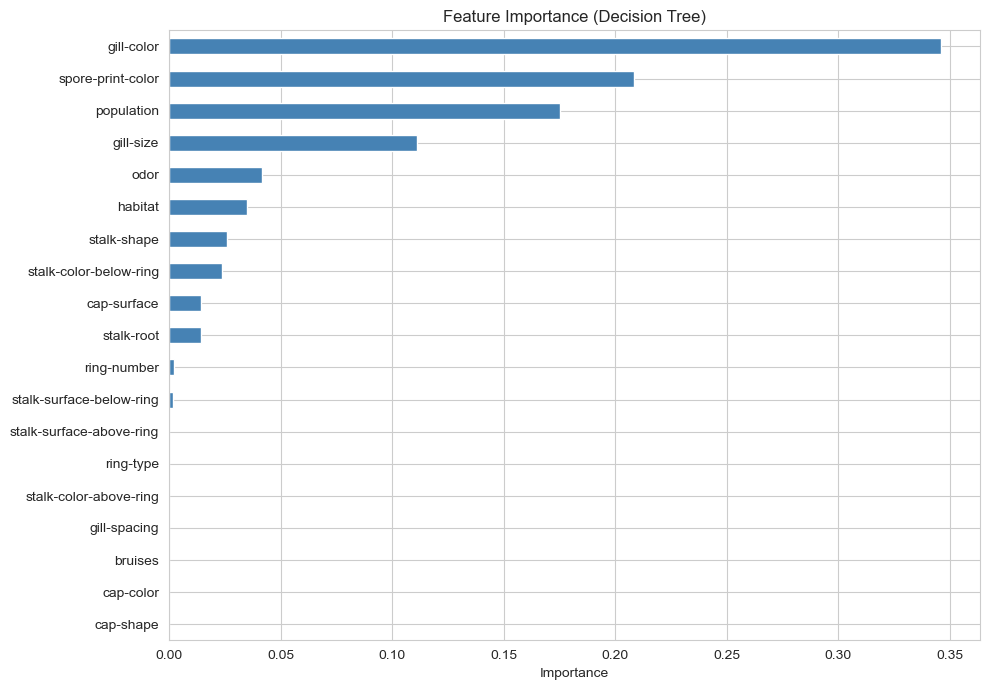

In [ ]:
best_dt = grid_search.best_estimator_
importances = pd.Series(best_dt.feature_importances_, index=X_all.drop(columns=['class']).columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
importances.plot.barh(ax=ax, color='steelblue')
ax.set_title('Feature Importance (Decision Tree)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### 2. Permutation Importance

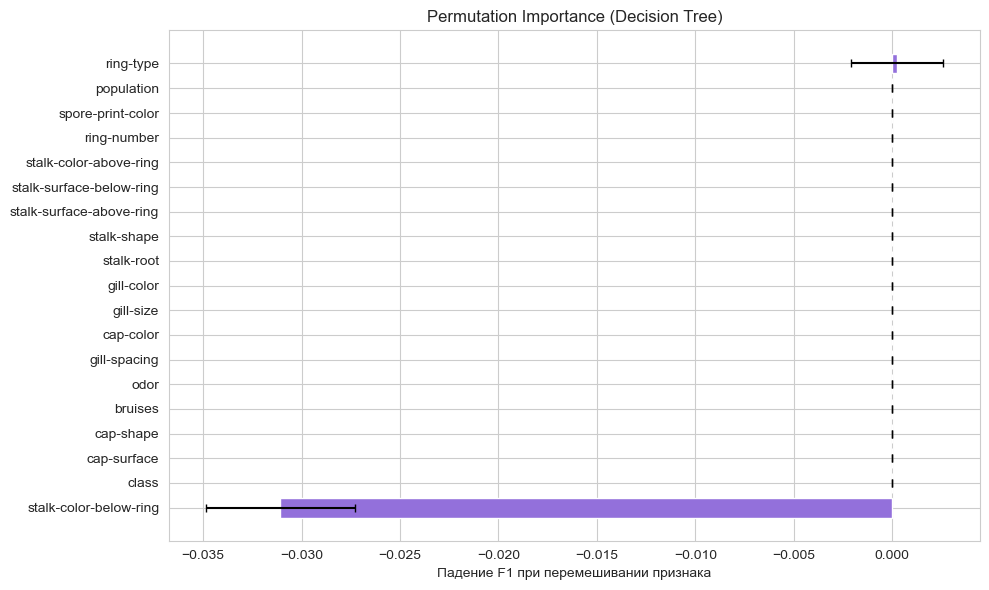

In [156]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(best_dt, X_test, y_test_cls, n_repeats=10,
                              random_state=42, scoring='f1_macro', n_jobs=-1)
order = perm.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(np.array(numeric_cols)[order], perm.importances_mean[order],
        xerr=perm.importances_std[order], color='mediumpurple', capsize=3)
ax.set_title('Permutation Importance (Decision Tree)')
ax.set_xlabel('Падение F1 при перемешивании признака')
plt.tight_layout(); plt.show()

## Отбор признаков

### 1. Variance Threshold

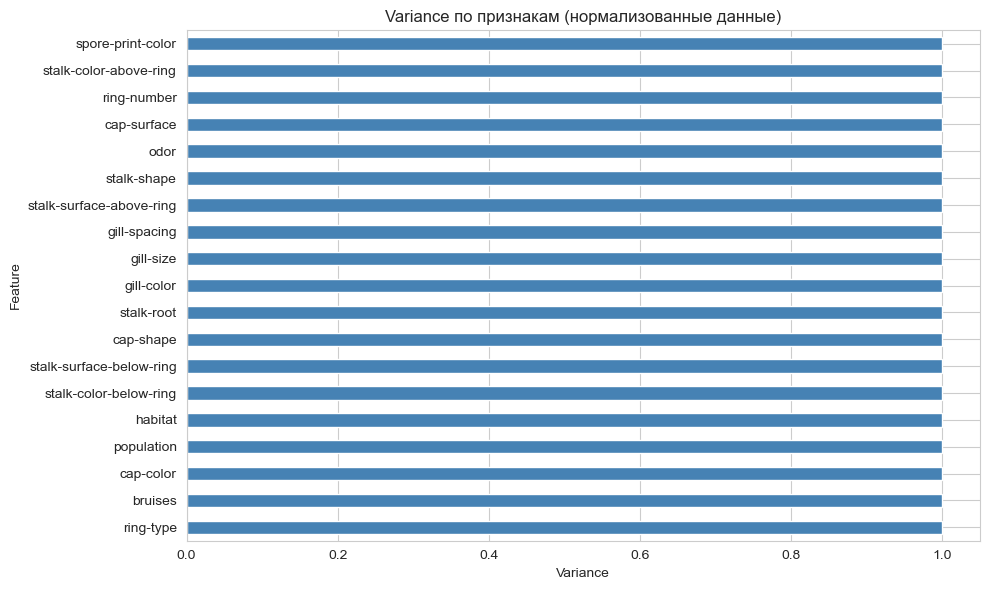

In [162]:
from sklearn.feature_selection import VarianceThreshold

variances = X_train_sc.var(axis=0)
var_df = pd.DataFrame({'Feature': X_all.drop(columns=['class']).columns, 'Variance': variances}).sort_values('Variance')

fig, ax = plt.subplots(figsize=(10, 6))
var_df.plot.barh(x='Feature', y='Variance', ax=ax, color='steelblue', legend=False)
ax.set_title('Variance по признакам (нормализованные данные)')
ax.set_xlabel('Variance')
plt.tight_layout()
plt.show()

### 2. Univariate Feature Selection — SelectKBest с f_classif / mutual_info

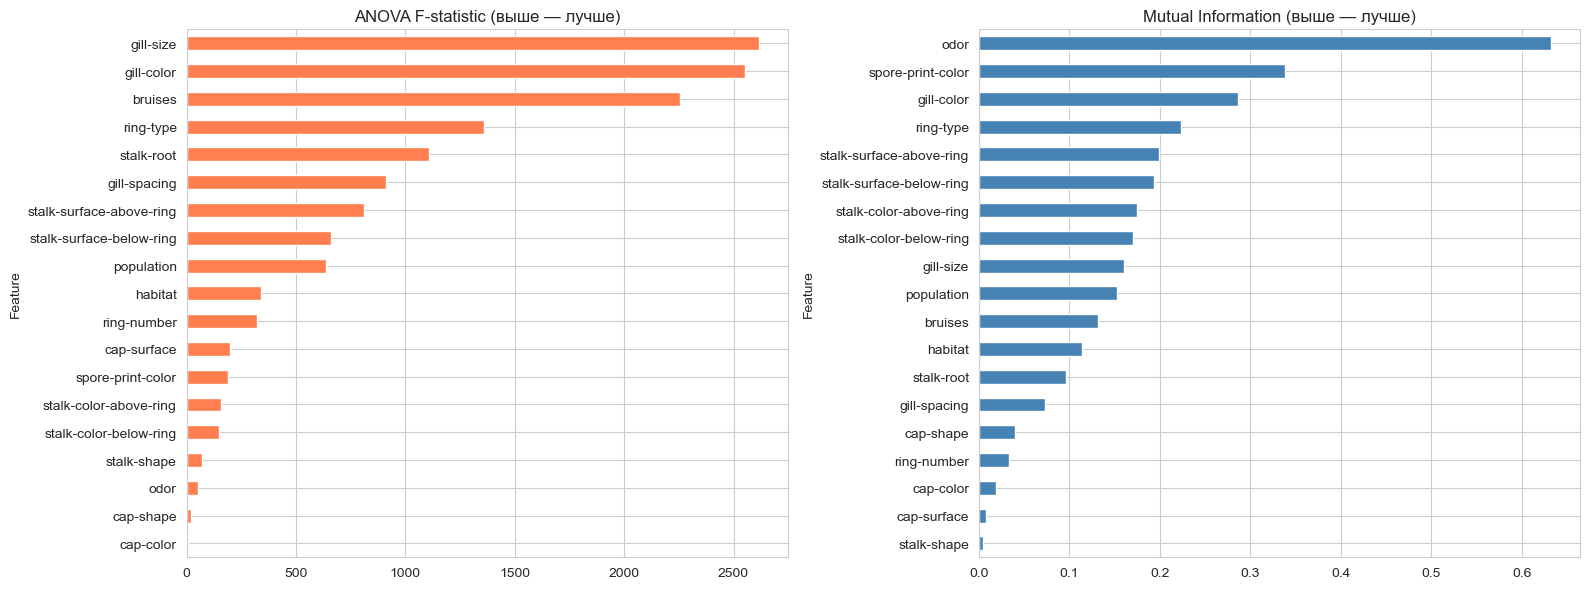

In [165]:
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

f_selector = SelectKBest(f_classif, k='all').fit(X_train_sc, y_train_cls)
mi_selector = SelectKBest(mutual_info_classif, k='all').fit(X_train_sc, y_train_cls)

scores_df = pd.DataFrame({
    'Feature': X_all.drop(columns = ['class']).columns,
    'F-statistic': f_selector.scores_,
    'Mutual Information': mi_selector.scores_
}).sort_values('F-statistic', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scores_df.sort_values('F-statistic').plot.barh(x='Feature', y='F-statistic', ax=axes[0], 
                                                 color='coral', legend=False)
axes[0].set_title('ANOVA F-statistic (выше — лучше)')

scores_df.sort_values('Mutual Information').plot.barh(x='Feature', y='Mutual Information', ax=axes[1], 
                                                        color='steelblue', legend=False)
axes[1].set_title('Mutual Information (выше — лучше)')

plt.tight_layout()
plt.show()